# TP2 Social Network

Victor Bouvier d'Acher  
Geoffroy Rodriguez  
Arezki Meriane  

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## PART 1 : Graph representation in Python

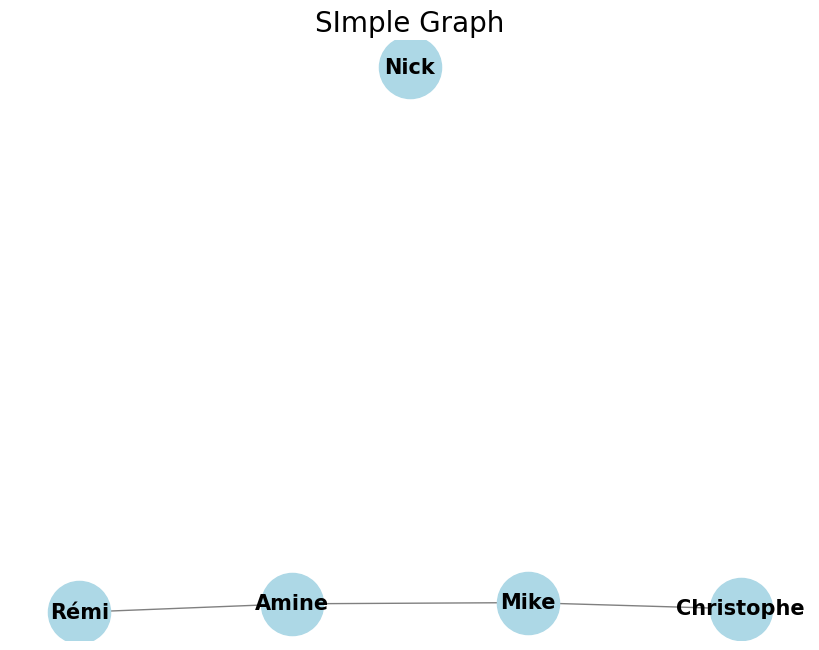

In [2]:
G = nx.Graph()
G.add_node("Mike")
G.add_nodes_from(["Amine", "Rémi", "Nick"])
G.add_edge("Mike", "Amine")
G.add_edge("Amine", "Rémi")
G.add_edge("Mike", "Christophe")

plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=15, 
        font_weight='bold', edge_color='gray')
plt.title("SImple Graph", size=20)
plt.show()

## PART 2 : Calculating centrality metrics using Python

   Node  Degree  Betweenness  Closeness
0     7   0.625     0.714286   0.727273
1     2   0.500     0.464286   0.615385
2     3   0.250     0.000000   0.533333
3     4   0.250     0.000000   0.470588
4     5   0.250     0.000000   0.470588
5     1   0.250     0.250000   0.500000
6     6   0.125     0.000000   0.347826
7     8   0.125     0.000000   0.400000
8     9   0.125     0.000000   0.400000


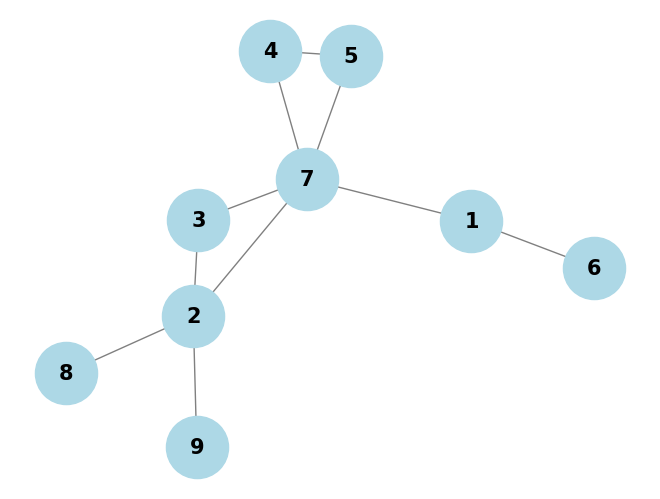

In [3]:
vertice = [(7,2), (2,3), (7,4), (4,5), (7,3), (7,5), (1,6), (1,7), (2,8), (2,9)]

G2 = nx.Graph()
G2.add_edges_from(vertice)

degree = nx.degree_centrality(G2)
between = nx.betweenness_centrality(G2)
close = nx.closeness_centrality(G2)

centrale = {
    "Node": list(degree.keys()),
    "Degree": list(degree.values()),
    "Betweenness": list(between.values()),
    "Closeness": list(close.values())
}

df_centrale = pd.DataFrame(centrale)
print(df_centrale)

nx.draw(G2, with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=15, 
        font_weight='bold', edge_color='gray')

5) On constate que le noeud numéro **7** est celui qui resort avec la valeur de degree, betweenness et closeness le **plus élevé**. Ceci s'explique, car le noeud **7** est le noeud le plus ayant **le plus de connection** ou **le degré le plus élevé**.  
On constate aussi que **plusieurs noeud** ont des valeurs de **betweenness** égale à **0** à savoir les noeuds **3, 4, 5, 6, 8, 9**, ce qui s'explique par ce soit ils n'ont qu'un **seul noeud voisin**, soit ses noeuds voisins ont les **mêmes noeuds en commun** (le noeuds 4 et 5 sont connecter au noeuds 7).
  


## PART 3 : Fraud analytics

In [4]:
def simple_method(G, neighbors, F, NF):
    F_count = sum(1 for n in neighbors if n in F)
    NF_count = len(neighbors) - F_count
    
    if F_count > NF_count:
        return "F"
    else:
        return "NF"

In [5]:
def watchower_method(G, neighbors, F, NF):
    between = nx.betweenness_centrality(G)

    F_count = sum(between[n] for n in neighbors if n in F)
    NF_count = sum(between[n] for n in neighbors if n in NF)

    if F_count > NF_count:
        return "F"
    else:
        return "NF"

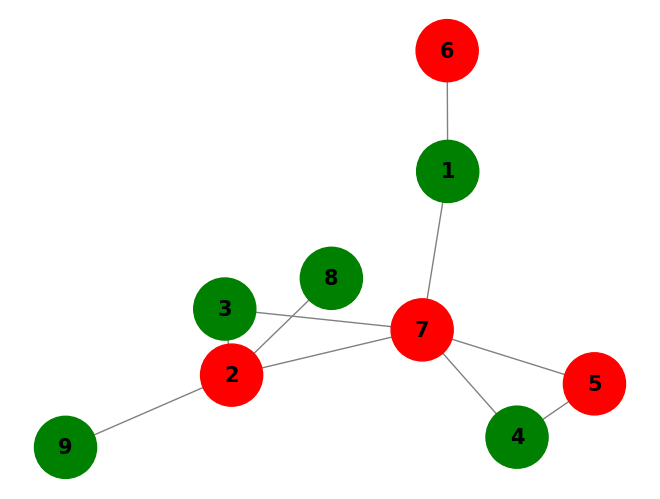

In [6]:
NF = [1, 4, 3, 8, 9]
F = [2, 5, 6, 7]

G3 = nx.Graph()
G3.add_edges_from(vertice)

node_colors = []
for n in G3.nodes():
    if n in F:
        node_colors.append('red')
    else:
        node_colors.append('green')
nx.draw(G3, with_labels=True, node_color=node_colors, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')


prediction de noeud q avec la methode simple : F
prediction de noeud q avec la methode watchower : F


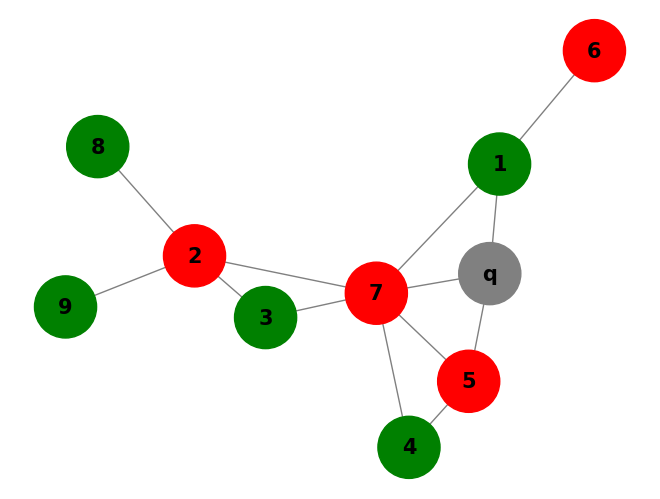

In [7]:
G3.add_node('q')
G3.add_edges_from([('q', 1), ('q', 7), ('q', 5)])  # Connect 'q' to some nodes

# List of neighbors for 'q'
q_neighbors = list(G3.neighbors('q'))
node_colors.append('gray')

nx.draw(G3, with_labels=True, node_color=node_colors, node_size=2000, font_size=15, font_weight='bold', edge_color='gray')


print(f'prediction de noeud q avec la methode simple : {simple_method(G3, q_neighbors, F, NF)}')
print(f'prediction de noeud q avec la methode watchower : {watchower_method(G3, q_neighbors, F, NF)}')

Avec la méthode simple, on detecte une **fraud** dans le noeuds **q** car **plus de la moitié** de ses **voisins sont aussi des fraud**.  
Avec la watchower method, on detecte que **q** est aussi une **fraud** car **q** a **plus de connection** (betwenness) avec des **fraud** qu'avec des non fraud. 


### Simple fraud analytics

In [8]:
def simple_fraud(G, neighbors, F, NF, threshold=0.5):
    
    poids = sum([1 for n in neighbors if n in F])

    prob = (1/len(neighbors)) * poids

    if prob > threshold:
        return 'F'
    return 'NF'



In [9]:
print(simple_fraud(G3, q_neighbors, F, NF))

F


Avec la simple fraud analytics, on trouve que **q** est une **fraud**.
Nous avons fixé un treshold à 0.5 car si les noeuds voisins ont une influence de plus de 50%, on considère que le noeuds est une fraud.
Pour les poids entre chaque noeud, nous avons fixé le poids de chaque aretes à 1 car nous ne connaissons pas les interactions entre les différents noeuds. Les resultats sont similaires qu'avec la simple method avec cette valeur, ce poids caractérise l'influence d'un noeuds sur le nouveau noeud. 

### The watchower fraud analytics methodology

In [10]:
def DOS(G, F, NF, fraud_value):
    degree = nx.degree_centrality(G)
    between = nx.betweenness_centrality(G)
    close = nx.closeness_centrality(G)
    eigen = nx.eigenvector_centrality(G)

    df_dos = pd.DataFrame({
        "Node": list(G.nodes()),
        "Degree": list(degree[n] for n in list(G.nodes())),
        "Betweenness": list(between[n] for n in list(G.nodes())),
        "Closeness": list(close[n] for n in list(G.nodes())),
        "Eigenvector": list(eigen[n] for n in list(G.nodes()))
    })

    df_dos["average"] = df_dos.mean(axis=1)

    df_dos["Outcome"] = df_dos["Node"].apply(lambda x: fraud_value[x])
    df_dos["DOS"] = df_dos["average"] * df_dos["Outcome"]
    
    df_dos["norm_DOS"] = df_dos["DOS"] / df_dos["DOS"].max()
    
    return df_dos

In [11]:
negative_outcome = {n:0 for n in G3.nodes()}
for f in F:
    nbr = list(G3.neighbors(f))
    nb = sum([1 for i in nbr if i in F])
    match nb:
        case 0:
            negative_outcome[f] = 6
        case 1:
            negative_outcome[f] = 7
        case 2:
            negative_outcome[f] = 8
        case _:
            negative_outcome[f] = 10


df_dos = DOS(G3, F, NF, negative_outcome)

/tmp/ipykernel_10246/2727768289.py:15: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_dos["average"] = df_dos.mean(axis=1)


Nous avons calculer la valeur de negative outcome en fonction du nombre de voisin frauduleux si le noeud est frauduleux.  
si 0 -> 6  
si 1 -> 7  
si 2 -> 8  
si >2 -> 10  

In [12]:
print(df_dos)

  Node    Degree  Betweenness  Closeness  Eigenvector   average  Outcome  \
0    7  0.666667     0.652778   0.750000     0.580917  0.662590        8   
1    2  0.444444     0.416667   0.600000     0.310102  0.442803        7   
2    3  0.222222     0.000000   0.529412     0.267195  0.254707        0   
3    4  0.222222     0.000000   0.473684     0.286526  0.245608        0   
4    5  0.333333     0.013889   0.500000     0.374567  0.305447        7   
5    1  0.333333     0.222222   0.529412     0.317166  0.350533        0   
6    6  0.111111     0.000000   0.360000     0.095110  0.141555        6   
7    8  0.111111     0.000000   0.391304     0.092993  0.148852        0   
8    9  0.111111     0.000000   0.391304     0.092993  0.148852        0   
9    q  0.333333     0.027778   0.529412     0.381636  0.318040        0   

        DOS  norm_DOS  
0  5.300722  1.000000  
1  3.099623  0.584755  
2  0.000000  0.000000  
3  0.000000  0.000000  
4  2.138132  0.403366  
5  0.000000  0.0000

Il y a 4 DOS différente :  
7 -> 5.30  
2 -> 3.09   
5 -> 2.13  
6 -> 0.85  

7 est le plus élevé car il est le noeud avec le plus de gros average dans les noeuds frauduleux, en effet il est premier dans toutes les caractéristique: Degree, Betweenness, Closeness, Eigenvector. 
6 est le plus faible car il est le noeud avec le plus petit average dans les noeuds frauduleux.

La différence entre le noeuds 7 et 6 est leurs influences par rapport au autre noeuds.  
6 est excentré avec très peu de connection alors que 7 est centré avec beaucoup de connection.

In [13]:
def DOS_method(G, neighbors, F, NF, df_dos):

    dico = {n:d for n, d in zip(df_dos["Node"], df_dos["norm_DOS"])}
    poids = sum([1*dico[n] for n in neighbors if n in F])

    prob = (1/len(neighbors)) * poids

    if prob == 0:
        return "No risk"
    if prob > 0 and prob <= 0.1:
        return "Low risk"
    if prob > 0.1 and prob <= 0.3:
        return "Medium risk"
    if prob > 0.3:
        return "High risk"



In [14]:
print(DOS_method(G3, q_neighbors, F, NF, df_dos))

High risk


Le DOS du noeud **q** est **0.46** ce qui peux etre considerer comme un **High Risk** dans la classification. La raison de cette valeur est que **q** est voisin de **2 fraud**, **5 et 7**, avec 7 le DOS le plus **élevé**.